In [3]:
import pandas as pd
import numpy as np
df=pd.read_csv("/content/placement.csv")

In [4]:
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [6]:
#remove useless col and row ,preprocessing
df=df.iloc[:,1:]

In [7]:
#EDA
import matplotlib.pyplot as plt

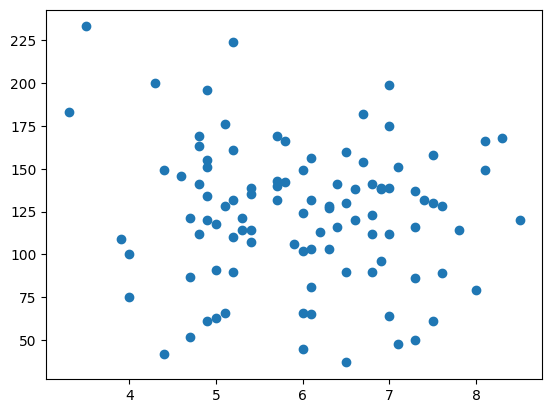

In [9]:
plt.scatter(df['cgpa'],df['iq'])

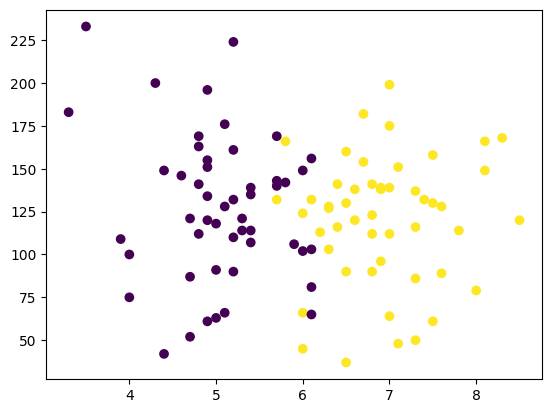

In [14]:
plt.scatter(df['cgpa'],df['iq'],c=df['placement'])#shows classification by graph

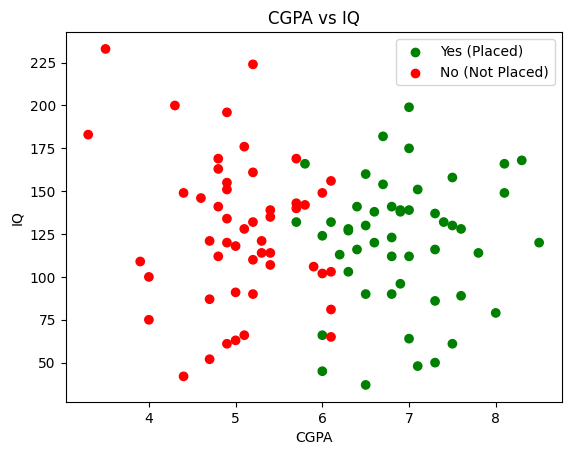

In [19]:
colors = df['placement'].map({
    1: 'green',
    0: 'red'
})
plt.scatter(df['cgpa'],df['iq'],c=colors)
#plt.scatter(df['cgpa'], df['iq'], c=colors)

plt.xlabel('CGPA')
plt.ylabel('IQ')
plt.title('CGPA vs IQ')
# Add legend
plt.scatter([], [], color='green', label='Yes (Placed)')
plt.scatter([], [], color='red', label='No (Not Placed)')

plt.legend()
plt.show()


In [67]:
#extract input and output col
X=df.iloc[:,0:2]
Y=df.iloc[:,-1]


In [25]:
X

,cgpa,iq
0,6.8,123.0
1,5.9,106.0
2,5.3,121.0
3,7.4,132.0
4,5.8,142.0
...,...,...
95,4.3,200.0
96,4.4,42.0
97,6.7,182.0
98,6.3,103.0


In [26]:
Y

,placement
0,1
1,0
2,0
3,1
4,0
...,...
95,0
96,0
97,1
98,1


In [68]:
#Train test split
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.1)

In [29]:
X_train

,cgpa,iq
57,6.5,130.0
86,5.1,128.0
68,4.0,75.0
38,6.5,160.0
23,4.7,87.0
...,...,...
83,7.5,130.0
88,4.4,149.0
37,8.1,149.0
98,6.3,103.0


In [30]:
X_test

,cgpa,iq
76,4.9,155.0
15,5.1,176.0
66,6.9,96.0
34,4.8,163.0
30,7.6,128.0
51,4.8,141.0
56,6.1,65.0
94,4.7,52.0
39,4.6,146.0
0,6.8,123.0


In [31]:
Y_train

,placement
57,1
86,0
68,0
38,1
23,0
...,...
83,1
88,0
37,1
98,1


In [32]:
Y_test

,placement
76,0
15,0
66,1
34,0
30,1
51,0
56,0
94,0
39,0
0,1


In [70]:
#scalling
from sklearn.preprocessing import StandardScaler
scaler= StandardScaler()

In [71]:
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [69]:
X_train

,cgpa,iq
51,4.8,141.0
79,6.5,90.0
1,5.9,106.0
68,4.0,75.0
77,7.3,50.0
...,...,...
6,5.7,143.0
42,7.6,89.0
39,4.6,146.0
87,5.7,132.0


In [72]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression()

In [73]:
#model training
model.fit(X_train,Y_train)

LogisticRegression()

In [74]:
#evaluate
y_pred=model.predict(X_test)

In [75]:
from sklearn.metrics import accuracy_score
accuracy_score(Y_test,y_pred)

0.9

In [76]:
#how to plot decision boundary that logistic regreeison learn from data
from mlxtend.plotting import plot_decision_regions

<Axes: >

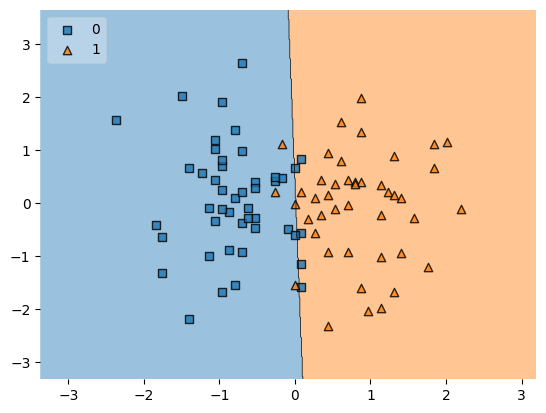

In [77]:
# Plotting decision regions
plot_decision_regions(X_train, Y_train.values, clf=model, legend=2)

In [79]:
#saving model

import pickle
pickle.dump(model,open('model.pkl','wb'))